In [7]:
import sys
print(sys.executable)

d:\Emi Predict\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np

In [30]:
df = pd.read_csv('D:\emi_prediction_dataset.csv')

<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_8388\3706709170.py:1: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv('D:\emi_prediction_dataset.csv')
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_8388\3706709170.py:1: DtypeWarning: Columns (0: age) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\emi_prediction_dataset.csv')


In [31]:
df

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404795,27.0,Male,Married,Graduate,32400.0,Private,5.0,Large Indian,Rented,10400.0,...,No,0.0,649.0,62000.0,32600.0,Personal Loan EMI,506000.0,47,Not_Eligible,500.0
404796,38.0,Male,Married,Post Graduate,49200.0,Private,1.9,MNC,Own,0.0,...,No,0.0,712.0,142200.0,38100.0,Personal Loan EMI,708000.0,33,Not_Eligible,5200.0
404797,32.0,Male,Single,Graduate,25700.0,Private,3.2,MNC,Rented,6300.0,...,No,0.0,676.0,191600.0,39700.0,Home Appliances EMI,93000.0,21,High_Risk,5665.0
404798,48.0,Male,Married,Graduate,47200.0,Private,3.0,MNC,Own,0.0,...,No,0.0,784.0,170400.0,45600.0,Home Appliances EMI,144000.0,36,Eligible,14460.0


In [13]:
df.shape

(404800, 27)

In [14]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='str')

In [17]:
print(df.dtypes)

age                        object
gender                        str
marital_status                str
education                     str
monthly_salary                str
employment_type               str
years_of_employment       float64
company_type                  str
house_type                    str
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans                str
current_emi_amount        float64
credit_score              float64
bank_balance                  str
emergency_fund            float64
emi_scenario                  str
requested_amount          float64
requested_tenure            int64
emi_eligibility               str
max_monthly_emi           float64
dtype: object


In [18]:
df.select_dtypes(include=['int64', 'float64','str']).columns.tolist()

['gender',
 'marital_status',
 'education',
 'monthly_salary',
 'employment_type',
 'years_of_employment',
 'company_type',
 'house_type',
 'monthly_rent',
 'family_size',
 'dependents',
 'school_fees',
 'college_fees',
 'travel_expenses',
 'groceries_utilities',
 'other_monthly_expenses',
 'existing_loans',
 'current_emi_amount',
 'credit_score',
 'bank_balance',
 'emergency_fund',
 'emi_scenario',
 'requested_amount',
 'requested_tenure',
 'emi_eligibility',
 'max_monthly_emi']

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object','str']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (15): ['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (12): ['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']


In [22]:
missing_count = df.isnull().sum()
print(missing_count)

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64


In [24]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.describe()

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


In [27]:
df[df.duplicated()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi


In [28]:
for col in categorical_cols:
    print(f"{col} : {df[col].nunique()} unique values")
    print(f"  Values: {df[col].unique()}")
    print("-" * 50)

age : 41 unique values
  Values: [38.0 58.0 48.0 32.0 27.0 47.0 37.0 31.0 59.0 49.0 33.0 26.0 39.0 57.0
 28.0 '58' '38' '48' '32' '27' '37' '48.0' '33' '38.0' '49' '27.0' '31'
 '39' '47' '59' '32.0' '58.0' '57' '26' '28' '58.0.0' '39.0' '26.0' '37.0'
 '38.0.0' '32.0.0']
--------------------------------------------------
gender : 8 unique values
  Values: <StringArray>
['Female', 'Male', 'female', 'male', 'M', 'MALE', 'F', 'FEMALE']
Length: 8, dtype: str
--------------------------------------------------
marital_status : 2 unique values
  Values: <StringArray>
['Married', 'Single']
Length: 2, dtype: str
--------------------------------------------------
education : 4 unique values
  Values: <StringArray>
['Professional', 'Graduate', 'High School', 'Post Graduate', nan]
Length: 5, dtype: str
--------------------------------------------------
monthly_salary : 13662 unique values
  Values: <StringArray>
[ '82600.0',  '21500.0',  '86100.0',  '66800.0',  '57300.0',  '38800.0',
  '27100.0', '

In [ ]:
import pandas as pd

columns = [
    'age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees'
]
unique_values = {}

for col in columns:
    if col in dfc.columns:
        unique_values[col] = sorted(dfc[col].dropna().astype(str).unique())
    else:
        unique_values[col] = []

print("Unique values for each column:\n")
for col, values in unique_values.items():
    print(f"{col}: {values}\n")

Unique values for each column:

age: ['26', '27', '28', '31', '32', '33', '37', '38', '39', '47', '48', '49', '57', '58', '59']

gender: ['Female', 'Male']

marital_status: ['Married', 'Single']

education: ['Graduate', 'High School', 'Post Graduate', 'Professional']

monthly_salary: ['10000', '100000', '10003', '10004', '10008', '100100', '10012', '10013', '10015', '10020', '100200', '10021', '10023', '100242', '10025', '10026', '10028', '10030', '100300', '10034', '10035', '100369', '10038', '100396', '100400', '100423', '100429', '100448', '10047', '100475', '100484', '10050', '100500', '10052', '10053', '10055', '100555', '10056', '10057', '10058', '10059', '100600', '100602', '100617', '100635', '10064', '10065', '100668', '10068', '100680', '100700', '10071', '100713', '10072', '10075', '10077', '10079', '100800', '10082', '10083', '10086', '10087', '10089', '10090', '100900', '10092', '10098', '10100', '101000', '10102', '10103', '10104', '10105', '10107', '101100', '101103', '1

In [ ]:
import pandas as pd

columns = [
    'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'
]
unique_values = {}

for col in columns:
    if col in dfc.columns:
        unique_values[col] = sorted(dfc[col].dropna().astype(str).unique())
    else:
        unique_values[col] = []

print("Unique values for each column:\n")
for col, values in unique_values.items():
    print(f"{col}: {values}\n")

Unique values for each column:

travel_expenses: ['1000', '10000', '10100', '10200', '10300', '10400', '10500', '10600', '10700', '10800', '10900', '1100', '11000', '11100', '11200', '11300', '11400', '11500', '11600', '11700', '11800', '11900', '1200', '12000', '12100', '12200', '12300', '12400', '12500', '12600', '12700', '12800', '12900', '1300', '13000', '13100', '13200', '13300', '13400', '13500', '13600', '13700', '13800', '13900', '1400', '14000', '14100', '14200', '14300', '14400', '14500', '14600', '14700', '14800', '14900', '1500', '15000', '15100', '15200', '15300', '15400', '15500', '15600', '15700', '15800', '15900', '1600', '16000', '16100', '16200', '16300', '16400', '16500', '16600', '16700', '16800', '16900', '1700', '17000', '17100', '17200', '17300', '17400', '17500', '17600', '17700', '17800', '17900', '1800', '18000', '18100', '18200', '18300', '18400', '18500', '18600', '18700', '18800', '18900', '1900', '19000', '19100', '19200', '19300', '19400', '19500', '19600

In [65]:
dfc = df.copy()

In [ ]:
dfc

In [67]:
import numpy as np

bool_cols = ['existing_loans']

for col in bool_cols:
    dfc[col] = dfc[col].replace(['', ' ', 'NA', 'N/A', None, 'None'], np.nan)


bool_map = {
    True: 1,
    'True': 1,
    'true': 1,
    'Yes': 1,
    'yes': 1,
    'Y': 1,
    'y': 1,
     1: 1,
    
     False: 0,
    'False': 0,
    'false': 0,
    'No': 0,
    'no': 0,
    'N': 0,
    'n': 0,
     0: 0
}


for col in bool_cols:
    dfc[col] = dfc[col].map(bool_map)

In [68]:
dfc.columns = dfc.columns.str.strip()

category_map = {
    'F': 'Female',
    'FEMALE': 'Female',
    'f': 'Female',
    'female': 'Female',
    'Female': 'Female',
    
    'M': 'Male',
    'MALE': 'Male',
    'Male': 'Male',
    'male': 'Male',
    'm': 'Male'
}

dfc['gender'] = dfc['gender'].replace(category_map)

In [69]:
dfc['age'] = dfc['age'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['monthly_salary'] = dfc['monthly_salary'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['monthly_rent'] = dfc['monthly_rent'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['school_fees'] = dfc['school_fees'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['college_fees'] = dfc['college_fees'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['travel_expenses'] = dfc['travel_expenses'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['groceries_utilities'] = dfc['groceries_utilities'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['other_monthly_expenses'] = dfc['other_monthly_expenses'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['current_emi_amount'] = dfc['current_emi_amount'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
dfc['credit_score'] = dfc['credit_score'].astype(str).str.replace(r'\.0+','', regex=True).str.strip() 
dfc['bank_balance'] = dfc['bank_balance'].astype(str).str.replace(r'\.0+','', regex=True).str.strip() 
dfc['emergency_fund'] = dfc['emergency_fund'].astype(str).str.replace(r'\.0+','', regex=True).str.strip() 
dfc['requested_amount'] = dfc['requested_amount'].astype(str).str.replace(r'\.0+','', regex=True).str.strip() 
dfc['max_monthly_emi'] = dfc['max_monthly_emi'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()

In [73]:
dfc['education'].unique()

<StringArray>
['Professional', 'Graduate', 'High School', 'Post Graduate', nan]
Length: 5, dtype: str

In [56]:
dfc['max_monthly_emi'] = dfc['max_monthly_emi'].astype(float).astype(int)

In [57]:
dfc['max_monthly_emi'].unique()

array([  500,   700, 27775, ..., 38065, 49860, 23730], shape=(13749,))

In [ ]:
missing_df = pd.DataFrame({
    'Missing Count': dfc.isnull().sum(),
    'Missing Percentage': (dfc.isnull().sum() / len(dfc)) * 100
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

                Missing Count  Missing Percentage
monthly_rent             2426            0.599308
bank_balance             2426            0.599308
credit_score             2420            0.597826
education                2404            0.593874
emergency_fund           2351            0.580781


In [74]:
cols_to_check = ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']

print(dfc[cols_to_check].apply(pd.to_numeric, errors='coerce').skew())

monthly_rent      1.612384
bank_balance      1.414794
credit_score     -1.094064
emergency_fund    1.790000
dtype: float64


In [75]:
cols_to_check = ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']
dfc[cols_to_check] = dfc[cols_to_check].apply(pd.to_numeric, errors='coerce')
for col in cols_to_check:
    Q1 = dfc[col].quantile(0.25)
    Q3 = dfc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = dfc[(dfc[col] < lower) | (dfc[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(dfc)*100, 2)}%)")

monthly_rent — Outliers: 12720 (3.14%)
bank_balance — Outliers: 13026 (3.22%)
credit_score — Outliers: 5840 (1.44%)
emergency_fund — Outliers: 17542 (4.33%)


In [76]:
mean_cols = ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']

for col in mean_cols:
    dfc[col] = dfc[col].fillna(dfc[col].median())
    

print("median imputation done!")

median imputation done!


In [ ]:
dfc['education'].unique()

<StringArray>
['Professional', 'Graduate', 'High School', 'Post Graduate', nan]
Length: 5, dtype: str

In [ ]:
print(dfc['education'].mode())

0    Graduate
Name: education, dtype: str


In [84]:
print(dfc.dtypes)

age                         int64
gender                        str
marital_status                str
education                     str
monthly_salary              int64
employment_type               str
years_of_employment       float64
company_type                  str
house_type                    str
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees                 int64
college_fees                int64
travel_expenses             int64
groceries_utilities         int64
other_monthly_expenses      int64
existing_loans              int64
current_emi_amount          int64
credit_score                int64
bank_balance                int64
emergency_fund              int64
emi_scenario                  str
requested_amount            int64
requested_tenure            int64
emi_eligibility               str
max_monthly_emi           float64
dtype: object


In [83]:
dfc['age'] = dfc['age'].astype('int')
dfc['monthly_salary'] = dfc['monthly_salary'].astype('int')
dfc['college_fees'] = dfc['college_fees'].astype('int')
dfc['school_fees'] = dfc['school_fees'].astype('int')
dfc['groceries_utilities'] = dfc['groceries_utilities'].astype('int')
dfc['travel_expenses'] = dfc['travel_expenses'].astype('int')
dfc['current_emi_amount'] = dfc['current_emi_amount'].astype('int')
dfc['credit_score'] = dfc['credit_score'].astype('int')
dfc['bank_balance'] = dfc['bank_balance'].astype('int')
dfc['emergency_fund'] = dfc['emergency_fund'].astype('int')
dfc['requested_amount'] = dfc['requested_amount'].astype('int')
dfc['other_monthly_expenses'] = dfc['other_monthly_expenses'].astype('int')
dfc['max_monthly_emi'] = dfc['max_monthly_emi'].astype('float')

In [85]:
# Update numerical and categorical columns after dtype changes
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")



Numerical columns (15): ['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (12): ['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']


C:\Users\Windows 10\AppData\Local\Temp\ipykernel_8388\250222765.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [94]:
print(dfc[numerical_cols].skew().sort_values(ascending=False))

college_fees              1.040627
requested_tenure          0.918680
school_fees               0.584345
current_emi_amount        0.415194
monthly_rent              0.378475
family_size               0.022211
dependents                0.022211
groceries_utilities      -0.181008
travel_expenses          -0.183910
other_monthly_expenses   -0.213300
requested_amount         -0.273279
max_monthly_emi          -0.334171
years_of_employment      -0.470603
emergency_fund           -0.656365
credit_score             -1.097378
dtype: float64


In [93]:
skewed_cols = ['years_of_employment','max_monthly_emi','emergency_fund','current_emi_amount','monthly_rent','college_fees',
              'other_monthly_expenses', 'requested_amount', 'travel_expenses', 'groceries_utilities' ]

for col in skewed_cols:
    dfc[col] = np.log1p(dfc[col])

print("Log Transform done!")

Log Transform done!


In [95]:
for col in numerical_cols:
    Q1 = dfc[col].quantile(0.25)
    Q3 = dfc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = dfc[(dfc[col] < lower) | (dfc[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(dfc)*100, 2)}%)")

years_of_employment — Outliers: 0 (0.0%)
monthly_rent — Outliers: 0 (0.0%)
family_size — Outliers: 0 (0.0%)
dependents — Outliers: 0 (0.0%)
school_fees — Outliers: 0 (0.0%)
college_fees — Outliers: 0 (0.0%)
travel_expenses — Outliers: 1360 (0.34%)
groceries_utilities — Outliers: 936 (0.23%)
other_monthly_expenses — Outliers: 953 (0.24%)
current_emi_amount — Outliers: 0 (0.0%)
credit_score — Outliers: 5840 (1.44%)
emergency_fund — Outliers: 6090 (1.5%)
requested_amount — Outliers: 2298 (0.57%)
requested_tenure — Outliers: 7730 (1.91%)
max_monthly_emi — Outliers: 0 (0.0%)


Missing columns: []


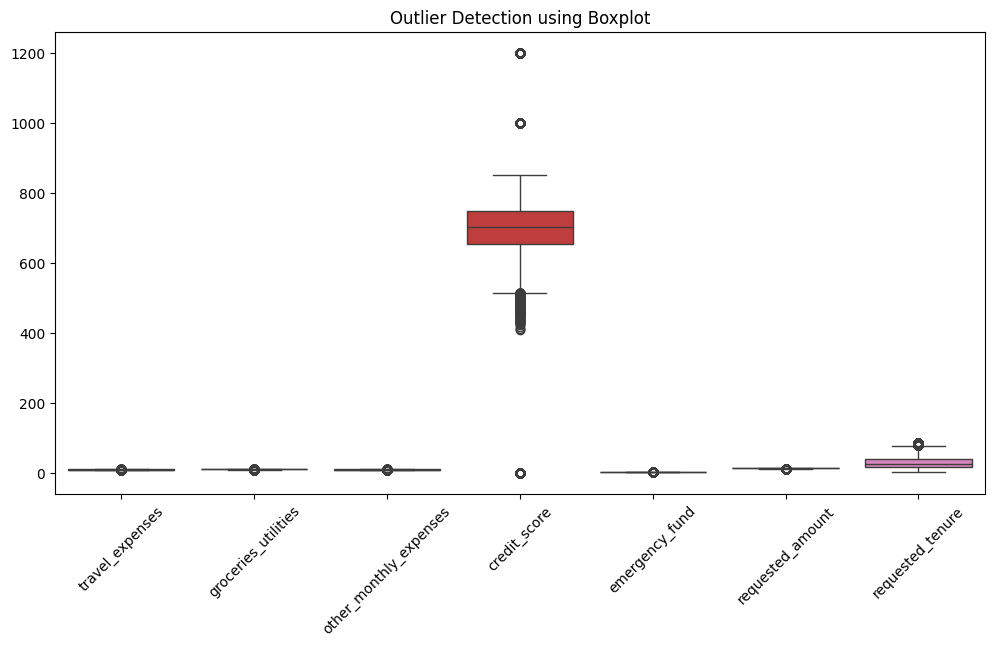

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

outlier_cols = [
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'credit_score',
    'emergency_fund',
    'requested_amount',
    'requested_tenure'
]
valid_cols = [col for col in outlier_cols if col in dfc.columns]
missing_cols = [col for col in outlier_cols if col not in dfc.columns]
print("Missing columns:", missing_cols)
plt.figure(figsize=(12,6))
sns.boxplot(data=dfc[valid_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection using Boxplot")
plt.show()

In [103]:
numerical_cols = dfc.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = dfc.select_dtypes(include=['object','str']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (19): ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (8): ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'emi_scenario', 'emi_eligibility']


In [105]:
for col in numerical_cols:
    if (dfc[col] < 0).any():
        print("Negative values detected in:", col)

print("No Negative values")

No Negative values


In [108]:
X = dfc.drop("max_monthly_emi", axis=1)
y = dfc["max_monthly_emi"]

In [111]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (283360, 26)
Validation: (60720, 26)
Test: (60720, 26)


In [101]:
dfc.to_csv(r"D:\Emi Predict\Data Cleaning\emi_prediction_clean.csv",header='infer',index=False)